### Exercise to conceptualize stochastic gradient descent (SGD), the mechanism by which a model updates weights to make better predictions, maximize performance, and minimize loss.

In [2]:
from fastai.vision.all import *

## initialize → predict → loss → gradient → step → repeat (until training is good enough)

### calculating gradients: measures how changing each weight would change the loss

In [6]:
def f(x): return x**2
# select a tensor value at which we want gradients (3.)
xt = tensor(3.).requires_grad_() # rewquires_grad_ : tags variable so pytorch can calculate gradients with respect to the variable at that value
yt = f(xt) 
yt

tensor(9., grad_fn=<PowBackward0>)

In [34]:
# actually calculate gradients (not done above)
yt.backward() # backward refers to backpropagation aka calculating derivative of each layer

In [ ]:
# view gradients by checking grad attribuute of tensor
xt.grad
# derivative of x**2 = 2*x, x = 3, so gradients should be 2*3=6 which is what was calculated below:

tensor(6.)

In [ ]:
# repeat preceding steps but with vector argument for function
xt = tensor([3., 4., 10.]).requires_grad_()

# add sum to function so it can take a vector and return a scalar
def f(x): return (x**2).sum() #sums numbers in returned vector
yt = f(xt)
yt

tensor(125., grad_fn=<SumBackward0>)

In [ ]:
yt.backward() # calculate gradients
xt.grad # view gradients
# gradients are 2*xt, as expected
# gradients only inform slope of function, but not how much to adjust parameters (see: learning rate!!)
# some intuition: if slope is large, may suggest more adjustments to be made; if slope is small, may suggest close to optimal value

tensor([ 6.,  8., 20.])

##### Deciding how to change params based on gradient values: Nearly all approaches begin with multiplying gradients by a small number called the learning rate (LR), which is usually between 0.001 and 0.1.

In [ ]:
# once you've picked a learning rate, you can adjust params by multiplying gradient by learning rate:
weight -= weight.grad * lr # aka stepping parameters, using *optimization step*


## End-to-end SGD Example: measuring speed of a roller coaster going over a hump

In [14]:
# example of measuring speed manually every second for 20s
time = torch.arange(0, 20).float()
time

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19.])

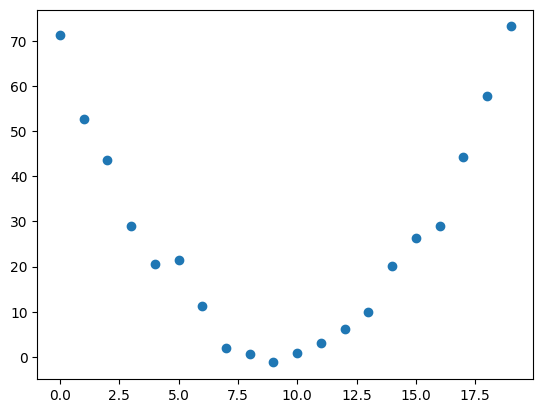

In [15]:
speed = torch.randn(20)*3 + 0.75*(time-9.5)**2 + 1 # introduce random noise to mimic imprecision of a manual measurement
plt.scatter(time, speed)

In [16]:
# attempt quadratic function to match above observations: ax**2 + bx + c; x == time
# distinguish between function's input (time) and its params (values that define which quadratic we're trying)
# the below function restricts the problem of finding the best params to finding the best quadratic function, aka we only need to find the best values for a, b, c as opposed to some larger vector with more params
def f(t, params):
    a, b, c = params
    return a*(t**2) + (b*t) + c # quadratic function

##### To define the 'best' params, choose a loss function that will return a lower value corresponding to a 'better' prediction. For continuous data (as opposed to discrete), it is common to use mean squared error (MSE):

In [17]:
# mse: mean of square root of differences, then square root
def mse(preds, targets): return ((preds - targets)**2).mean().sqrt()

### Step 1: Initialize the parameters (randomly), track gradients using PyTorch requires_grad_

In [38]:
params = torch.randn(3).requires_grad_()
params

tensor([-0.7495,  0.2810, -0.0098], requires_grad=True)

### Step 2: Calculate the predictions with quadratic formula function

In [39]:
preds = f(time, params)
preds # calculates preds for each value of x (time) vs. quadratic formula


tensor([-9.7777e-03, -4.7835e-01, -2.4460e+00, -5.9127e+00, -1.0878e+01,
        -1.7343e+01, -2.5307e+01, -3.4770e+01, -4.5732e+01, -5.8193e+01,
        -7.2153e+01, -8.7612e+01, -1.0457e+02, -1.2303e+02, -1.4298e+02,
        -1.6444e+02, -1.8739e+02, -2.1185e+02, -2.3780e+02, -2.6525e+02],
       grad_fn=<AddBackward0>)

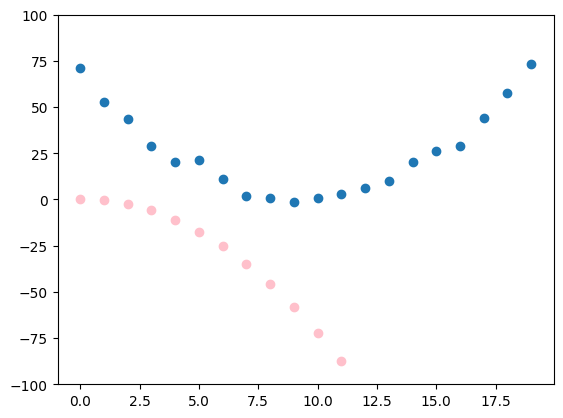

In [40]:
# create a function to see how close our predictions are to the targets
def show_preds(preds, ax = None):
    if ax is None: ax=plt.subplots()[1] # if no existing ax object, create one; plt.subplots returns (figure, axes) tuple, [1] will return axes otherwise object will have no attribute 'scatter' in next line
    ax.scatter(time, speed)
    ax.scatter(time, to_np(preds), color = 'pink') # to_np converts tensor to numpy array, since matplotlib can't plot tensors directly
    ax.set_ylim(-100, 100)
show_preds(preds)

### Step 3: Calculate the loss

In [41]:
loss = mse(preds, speed) # compare predictions with actual speed
loss


tensor(148.7628, grad_fn=<SqrtBackward0>)

### Step 4: Calculate the gradients to improve loss (Gradients = approximation of how the params need to change)

In [42]:
loss.backward() # calculate gradients since reguired_grads_ was originally called on params, which was input for f(x) to calculate preds, preds used to calculate mse, mse used to calculate loss
params.grad # view gradients

tensor([-165.2458,  -10.5623,   -0.7797])

In [43]:
params.grad * 1e-3 # learning rate = 0.001

tensor([-0.1652, -0.0106, -0.0008])

In [44]:
params # double check original params

tensor([-0.7495,  0.2810, -0.0098], requires_grad=True)

### Step 5: Step the weights -- Update the params based on the gradients we just calculated

In [ ]:
learning_rate = 1e-3
# to calculate gradients, call .backward on the loss BUT loss itself was calculated from mse, which took preds as an input, which was calculated using f taking params as an input
# params is the object we originally called required_grads_ on, which is the call that allowed us to call .backward on the loss SO we call params.data as the weight to adjust the params
params.data -= learning_rate * params.grad.data
params.grad = None # clear params.grad variable after updating params with learning rate


In [46]:
# check if the loss has improved
preds = f(time, params)
mse(preds, speed)

tensor(121.4384, grad_fn=<SqrtBackward0>)

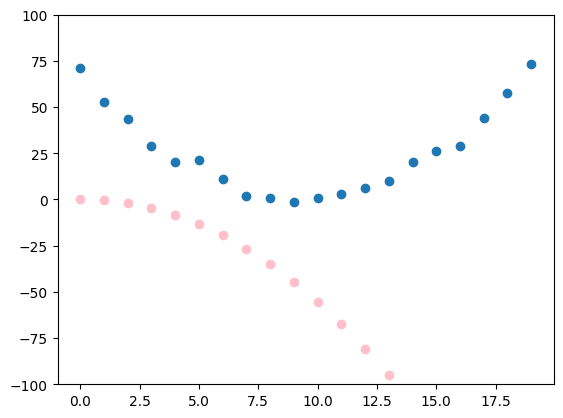

In [47]:
# it did improve by a tiny bit, check plot:
show_preds(preds)

In [ ]:
# create a function to repeat the stepping a few times
def apply_step(params, prn=True): # prn=True outputs iteration details (mse loss)
    preds = f(time, params)
    loss = mse(preds, speed)
    loss.backward()
    params.data -= learning_rate * params.grad.data
    params.grad = None
    if prn: print(loss.item())
    return preds # returns pred values at start of step, before params were updated

### Step 6: Repeat the process

In [51]:
# iterate; each iteration represents an entirely different quadratic function being tried
# range(10) = 10 epochs
for i in range(10): apply_step(params)

25.51873779296875
25.51857566833496
25.518417358398438
25.518259048461914
25.518098831176758
25.5179386138916
25.517780303955078
25.517621994018555
25.5174617767334
25.517303466796875


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

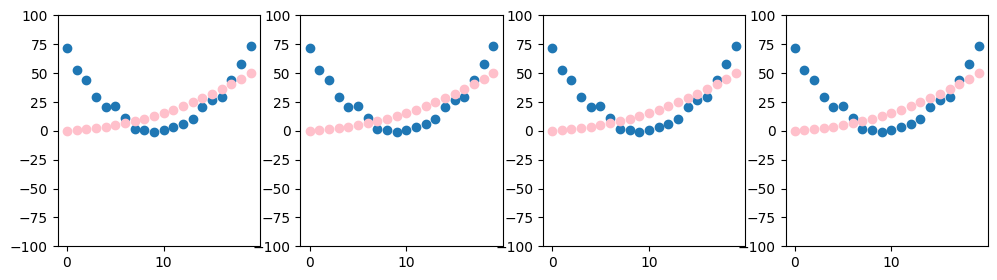

In [52]:
# plot the function at every step to see how graph approaches the 'best' possible function
_,axs = plt.subplots(1,4, figsize=(12,3))
for ax in axs: show_preds(apply_step(params, False), ax)
plt.tight_layout

39.38370132446289
27.45484733581543
26.163732528686523
26.162052154541016
26.161460876464844
26.16088104248047
26.16029930114746
26.159717559814453
26.15913963317871
26.158557891845703


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

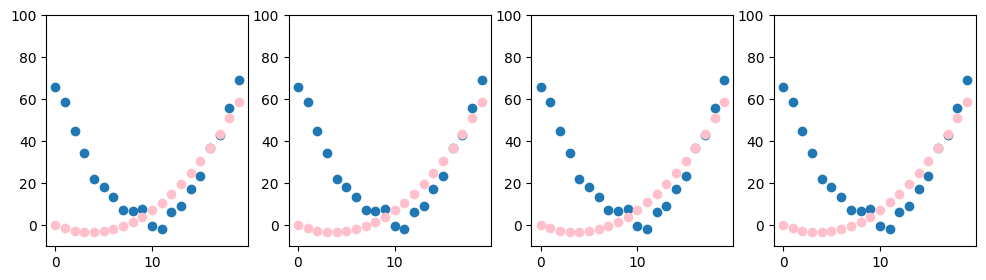

In [85]:
# increase learning rate out of curiosity
learning_rate = 1e-3
for i in range(10): apply_step(params) # range(10) = 10 epochs
_,axs = plt.subplots(1,4, figsize=(12,3))
for ax in axs: show_preds(apply_step(params, False), ax)
plt.tight_layout

